# Car vs Truck Modeling

This notebook is the modeling-focused part of the project report. It lightly covers the project context, then documents the baseline and proposed deep-learning models used for the binary image-classification task `car` vs `truck`.

The main goal is to compare one simple baseline (`SimpleCNN`) with two stronger transfer-learning approaches (`ResNet18` and `Swin-Tiny`). The notebook is written to run top to bottom. Its starts with the data loading and some preprocessing (not much is needed because the used CIFAR-10 Dataset is normalized and labeled to some extend) and the resulting datasets are used for the mentionned models to test and train. The model outputs then get evaluated with basic metrics. To get a better understanding of the models behavior, we using LIME to make parts of an example image visible that are influencing the models decision.

# Metadata

```yaml
project_title: "Image Classification between Car and Truck"
dataset_name: "CIFAR-10"
task_type: "binary_image_classification"
methods:
  - simple_cnn
  - resnet18_transfer_learning
  - swin_tiny_transfer_learning
evaluation_metrics:
  - accuracy
  - cross_entropy_loss
team_members:
  - name: Artur Schneider
    student_id:
    role: Data Preprocessing, Project Manager
  - name:
    student_id:
    role:
  - name:
    student_id:
    role:
  - name:
    student_id:
    role:  

submission_date: 
```


## AI Usage Declaration

| Item | Response |
|---|---|
| Did you use generative AI tools? | Yes /  |
| Which tools? | Microsoft Copilot  |
| For what purpose? | brainstorming and coding help |
| Which parts were AI-assisted? | Data Preprocessing |
| What did you verify yourself? |  |

### Short declaration
Copilot was used for Braistorming and elaborate on manual written code with giving feedback. Results were checked by comparing it with the taught content of the course (especially Laboratory). Intermediate Steps were visualized and printed out as much as possible to ensure plausibility and explainability.

## 1. Problem Definition and Motivation

## Contribution Metadata
Author(s): Artur Schneider

Section: Problem Definition and Motivation  
Method: [binary-classification, image-recognition]  
SHORT Description of contribution: Framed the modeling task and its motivation.

Difficulty: BASIC

The task is to classify an input image into one of two categories: `car` or `truck`. This is a compact supervised computer-vision problem that is suitable for comparing a simple convolutional baseline against stronger pretrained architectures. The task is relevant because it measures how well different modeling choices separate visually similar road-vehicle classes while keeping the label space small enough for clear analysis. In real-life it can be practical for traffic analysis. 


## 2. Dataset Description

## Contribution Metadata
Author(s): Artur Schneider

Section: Dataset Description  
Method: [cifar10-subset, binary-labels]  
SHORT Description of contribution: Summarized the dataset assumptions needed by the modeling notebook.

Difficulty: BASIC

This notebook expects two ready-to-use PyTorch datasets named `train_dataset` and `test_dataset`. Each dataset item must be a pair `(image_tensor, label)`, where the image has shape `(3, H, W)` and the label is encoded as `0` for `car` and `1` for `truck`. For this binary task we are using the CIFAR-10 Dataset by filtering the original automobile and truck classes. Its a well-known dataset with 10 classes (each class has 10000 train images and 2000 test images) that was researched a lot and providing data in good quality. We decided to use this for ensuring very good model outputs and save time.


## 3. Data Exploration and Preprocessing

## Contribution Metadata
Author(s):  
Section: Data Exploration and Preprocessing  
Method: [dataset-checks, dataloaders, normalization]  
SHORT Description of contribution: Documented the minimal preprocessing needed before model training.

Difficulty: INTERMEDIATE

 Inside this notebook, the main preprocessing steps are: validating that the datasets exist, building training and test dataloaders, inspecting one sample batch, and adapting the image format to each model family. The custom CNN can consume small CIFAR-style tensors directly, while the pretrained models additionally require resizing to `224 x 224` and ImageNet normalization to match their pretrained feature space.


In [ ]:
import os
import random
import time

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import CIFAR10
from torchvision.models import ResNet18_Weights, Swin_T_Weights, resnet18, swin_t
from torchvision.transforms.functional import pil_to_tensor


### Environment Setup

The next cell fixes the random seed and selects the best available device in the order `MPS -> CUDA -> CPU`. Keeping this logic near the top improves reproducibility and makes the hardware choice explicit.


In [ ]:
seed = 42
random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Device:", device)


### Dataset Loading
We are downloading the dataset from pytorch and filtering / relabeling it.
We also:
- convert images to tensors to use them as model input
- normalizing rgb values (from 0-255 to 0-1) so the model can process the images better. it also mitigates overflows. Another normalization step comes later for the batch preparing to ensure the rgb channels are seen as equal


In [ ]:
car_label = 1
truck_label = 9


class FilteredCIFAR10(torch.utils.data.Dataset):
    def __init__(self, train=True):
        self.dataset = CIFAR10(root="./data", train=train, download=True)
        self.indices = [
            i for i, label in enumerate(self.dataset.targets)
            if label in (car_label, truck_label)
        ]

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        image, original_label = self.dataset[self.indices[idx]]
        image = pil_to_tensor(image).float() / 255.0
        label = 0 if original_label == car_label else 1
        return image, label


if "train_dataset" not in globals() or "test_dataset" not in globals():
    train_dataset = FilteredCIFAR10(train=True)
    test_dataset = FilteredCIFAR10(train=False)
    print("Loaded filtered CIFAR-10 for local debugging.")
else:
    print("Using externally provided train_dataset and test_dataset.")


### Dataset Check and Hyperparameters

The following cell validates the expected dataset variables, holds out a fixed test loader, splits the remaining training data into fit and validation subsets (20% validation, reproducible via `random_split` and the notebook seed), builds the corresponding dataloaders, and defines the training hyperparameters used throughout the notebook. These values should be reported because they are part of the modeling design, not just implementation details.


In [ ]:
if "train_dataset" not in globals() or "test_dataset" not in globals():
    raise ValueError("Please define train_dataset and test_dataset before running this notebook.")

batch_size = 64
num_workers = 0
cnn_epochs = 10
resnet_epochs = 5
swin_epochs = 5
cnn_learning_rate = 1e-3
resnet_learning_rate = 1e-4
swin_learning_rate = 1e-4
save_dir = "saved_models"
os.makedirs(save_dir, exist_ok=True)

val_ratio = 0.2
split_gen = torch.Generator().manual_seed(seed)
n_total = len(train_dataset)
n_val = int(n_total * val_ratio)
n_train_split = n_total - n_val
train_subset, val_subset = random_split(
    train_dataset, [n_train_split, n_val], generator=split_gen
)

train_loader = DataLoader(
    train_subset, batch_size=batch_size, shuffle=True, num_workers=num_workers
)
val_loader = DataLoader(
    val_subset, batch_size=batch_size, shuffle=False, num_workers=num_workers
)
test_loader = DataLoader(
    test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers
)

print("Train samples (optimization):", len(train_subset))
print("Validation samples (per-epoch metrics):", len(val_subset))
print("Test samples (held out for final evaluation):", len(test_dataset))
print("Batch size:", batch_size)
print("Validation fraction (of train pool):", val_ratio)
print("Epochs -> CNN:", cnn_epochs, "ResNet18:", resnet_epochs, "Swin-Tiny:", swin_epochs)
print("Learning rates -> CNN:", cnn_learning_rate, "ResNet18:", resnet_learning_rate, "Swin-Tiny:", swin_learning_rate)
print("Loss function: CrossEntropyLoss")
print("Optimizer family: Adam")


### Sample Batch Inspection

A quick batch visualization confirms that the tensors, labels, and dataloader output look correct before training starts. This is the light-weight exploration needed in this modeling-focused notebook.


In [ ]:
images, labels = next(iter(train_loader))
display_images = images.float()
if display_images.max() > 1:
    display_images = display_images / 255.0

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Unique labels in this batch:", torch.unique(labels))

plt.figure(figsize=(10, 3))
for i in range(min(6, len(display_images))):
    plt.subplot(1, 6, i + 1)
    image = display_images[i].permute(1, 2, 0).cpu().clamp(0, 1)
    plt.imshow(image)
    plt.title(f"label={labels[i].item()}")
    plt.axis("off")
plt.tight_layout()
plt.show()


## 4. Baseline Model

## Contribution Metadata
Author(s): Amirmasoud Ahmadi Kolsaraki  
Section: Baseline Model  
Method: [simple-cnn, supervised-learning]  
SHORT Description of contribution: Implemented and justified the baseline convolutional network.

Difficulty: INTERMEDIATE

The baseline is a compact CNN trained from scratch. It provides a fair comparison point because it uses standard convolution, pooling, and fully connected layers without relying on pretrained external features. The model is intentionally simple: if the transfer-learning models improve on it, the gain can be attributed to stronger learned visual representations rather than extra task-specific engineering.


In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((4, 4)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 2),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


### Shared Training Utilities

All models use the same training and evaluation structure so the comparison stays consistent. The helper functions below also make explicit why the pretrained models need different input preparation from the baseline CNN.


In [ ]:
imagenet_mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
imagenet_std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)


def prepare_batch(images, model_type="cnn"):
    images = images.to(device).float()
    if images.max() > 1:
        images = images / 255.0

    if model_type in {"resnet", "swin"}:
        images = F.interpolate(images, size=(224, 224), mode="bilinear", align_corners=False)
        mean = imagenet_mean.to(images.device)
        std = imagenet_std.to(images.device)
        images = (images - mean) / std

    return images


def evaluate_model(model, dataloader, criterion, model_type="cnn"):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = prepare_batch(images, model_type=model_type)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * labels.size(0)
            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    loss_value = running_loss / total
    accuracy_value = correct / total
    return loss_value, accuracy_value


def train_model(model, train_loader, val_loader, criterion, optimizer, epochs, model_type="cnn"):
    history = {
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": [],
    }

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        start_time = time.time()

        for images, labels in train_loader:
            images = prepare_batch(images, model_type=model_type)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * labels.size(0)
            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_accuracy = correct / total
        val_loss, val_accuracy = evaluate_model(model, val_loader, criterion, model_type=model_type)
        epoch_time = time.time() - start_time

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_accuracy)

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"train loss: {train_loss:.4f} | "
            f"train acc: {train_accuracy:.4f} | "
            f"val loss: {val_loss:.4f} | "
            f"val acc: {val_accuracy:.4f} | "
            f"time: {epoch_time:.1f}s"
        )

    return history


def plot_history(history, title):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="Train loss")
    plt.plot(epochs, history["val_loss"], label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_accuracy"], label="Train accuracy")
    plt.plot(epochs, history["val_accuracy"], label="Validation accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title} Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()


def summarize_history(name, history):
    return {
        "model": name,
        "final_train_loss": history["train_loss"][-1],
        "final_train_accuracy": history["train_accuracy"][-1],
        "final_val_loss": history["val_loss"][-1],
        "final_val_accuracy": history["val_accuracy"][-1],
    }


### Baseline Training

The baseline CNN is trained with Adam and cross-entropy loss. The resulting curves and summary metrics establish the reference level that the proposed models should improve upon.


In [ ]:
simple_cnn = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
cnn_optimizer = torch.optim.Adam(simple_cnn.parameters(), lr=cnn_learning_rate)

cnn_history = train_model(
    model=simple_cnn,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=cnn_optimizer,
    epochs=cnn_epochs,
    model_type="cnn",
)

plot_history(cnn_history, "Simple CNN")

cnn_path = os.path.join(save_dir, "simple_cnn_car_truck.pth")
torch.save(simple_cnn.state_dict(), cnn_path)
print("Saved baseline CNN to:", cnn_path)
print(summarize_history("SimpleCNN", cnn_history))


## 5. Proposed Recommendation Model

## Contribution Metadata
Author(s): Amirmasoud Ahmadi Kolsaraki  
Section: Proposed Recommendation Model  
Method: [transfer-learning, resnet18, swin-tiny]  
SHORT Description of contribution: Implemented two proposed transfer-learning models and justified their design choices.

Difficulty: ADVANCED

Here the proposed approaches are two pretrained vision backbones fine-tuned for the `car` vs `truck` task: `ResNet18` and `Swin-Tiny`. Both replace the final classification head with a two-logit output layer and fine-tune all parameters instead of freezing the backbone. This keeps the comparison aligned while testing whether a pretrained CNN or a pretrained vision transformer adapts better to the binary dataset.

Because both backbones were originally trained on ImageNet, the input pipeline resizes images to `224 x 224` and applies ImageNet normalization before the forward pass. Those preprocessing steps are not needed for the simpler baseline CNN.


### Proposed Model A: ResNet18

`ResNet18` is a strong transfer-learning baseline because residual connections make optimization stable while still keeping the model compact enough for a class project. The final fully connected layer is replaced so the network predicts two classes instead of the original ImageNet categories.


In [ ]:
weights = ResNet18_Weights.DEFAULT
resnet_model = resnet18(weights=weights)
resnet_model.fc = nn.Linear(resnet_model.fc.in_features, 2)
resnet_model = resnet_model.to(device)

resnet_criterion = nn.CrossEntropyLoss()
resnet_optimizer = torch.optim.Adam(resnet_model.parameters(), lr=resnet_learning_rate)

resnet_history = train_model(
    model=resnet_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=resnet_criterion,
    optimizer=resnet_optimizer,
    epochs=resnet_epochs,
    model_type="resnet",
)

plot_history(resnet_history, "ResNet18")

resnet_path = os.path.join(save_dir, "resnet18_car_truck.pth")
torch.save(resnet_model.state_dict(), resnet_path)
print("Saved ResNet18 to:", resnet_path)
print(summarize_history("ResNet18", resnet_history))


### Proposed Model B: Swin-Tiny

`Swin-Tiny` adds a transformer-based alternative to the pretrained CNN. It uses shifted-window self-attention, which gives the project a second proposed architecture with a different inductive bias from `ResNet18`. The classification head is replaced with a two-class output layer so the fine-tuning setup remains parallel to the ResNet experiment.


In [ ]:
swin_weights = Swin_T_Weights.DEFAULT
swin_model = swin_t(weights=swin_weights)
swin_model.head = nn.Linear(swin_model.head.in_features, 2)
swin_model = swin_model.to(device)

swin_criterion = nn.CrossEntropyLoss()
swin_optimizer = torch.optim.Adam(swin_model.parameters(), lr=swin_learning_rate)

swin_history = train_model(
    model=swin_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=swin_criterion,
    optimizer=swin_optimizer,
    epochs=swin_epochs,
    model_type="swin",
)

plot_history(swin_history, "Swin-Tiny")

swin_path = os.path.join(save_dir, "swin_tiny_car_truck.pth")
torch.save(swin_model.state_dict(), swin_path)
print("Saved Swin-Tiny to:", swin_path)
print(summarize_history("Swin-Tiny", swin_history))


### Current Comparison Snapshot

The next cell prints the final metrics for the three trained models. This is enough to support the modeling section now, while a later version of the notebook can expand these outputs into the template's dedicated evaluation, results, and discussion sections.


In [ ]:
results = [
    summarize_history("SimpleCNN", cnn_history),
    summarize_history("ResNet18", resnet_history),
    summarize_history("Swin-Tiny", swin_history),
]

for row in results:
    print(row)


### Reproducibility Note

The notebook saves all trained weights under `saved_models/` and includes an example loading cell below. This is useful later when the full report reaches the reproducibility section, but it is already included here so the modeling outputs can be reused by teammates without retraining.


In [ ]:
loaded_cnn = SimpleCNN()
loaded_cnn.load_state_dict(torch.load(cnn_path, map_location="cpu"))
loaded_cnn.eval()

loaded_resnet = resnet18(weights=None)
loaded_resnet.fc = nn.Linear(loaded_resnet.fc.in_features, 2)
loaded_resnet.load_state_dict(torch.load(resnet_path, map_location="cpu"))
loaded_resnet.eval()

loaded_swin = swin_t(weights=None)
loaded_swin.head = nn.Linear(loaded_swin.head.in_features, 2)
loaded_swin.load_state_dict(torch.load(swin_path, map_location="cpu"))
loaded_swin.eval()

print("All saved models were loaded successfully.")


## 6. Evaluation Methodology

Models are compared on the held-out test set. Alongside accuracy, additional metrics are reported to describe error patterns and class separation between `car` and `truck`, rather than relying on a single summary statistic. Cross-entropy loss on the training set is minimized during optimization, while the metrics below are evaluated on the held-out test set to compare models and interpret classification outcomes.

**Confusion matrix.** For each model, a table of true negatives, false positives, false negatives, and true positives is constructed for `car` and `truck`. This indicates whether misclassification is symmetric (e.g., trucks labeled as cars versus cars labeled as trucks) and supports interpretation beyond overall accuracy.

**Per-class precision, recall, and F1.** For each label, precision, recall, and F1 are computed. **Precision** is the fraction of images assigned to a class that truly belong to that class (e.g., among all images predicted as truck, the fraction that are actually trucks). **Recall** is the fraction of all true instances of that class that receive the correct label (e.g., among all true trucks, the fraction predicted as truck). **F1** combines precision and recall into one value per class. Overall accuracy can remain high if one class is easier or more frequent; per-class metrics indicate whether performance is balanced across both vehicle categories.

**Macro-F1.** Macro-averaged F1 is used as the primary criterion for ranking models:

$$
F1_{\text{macro}} = \frac{F1_{\text{car}} + F1_{\text{truck}}}{2}
$$

Both classes contribute equally, which supports a balanced comparison between `car` and `truck`.

**Balanced accuracy.** The mean of the two class recalls is reported:

$$
\text{balanced accuracy} = \frac{\text{Recall}_{\text{car}} + \text{Recall}_{\text{truck}}}{2}
$$

This highlights whether both classes are retrieved with similar completeness, which is relevant when class frequencies differ or when errors on either class carry comparable cost.

**ROC-AUC.** This metric summarizes how well predicted probabilities rank images by class across all decision thresholds, not only at the fixed 0.5 cutoff.

**PR-AUC.** The area under the precision–recall curve provides a complementary assessment of probabilistic quality, particularly regarding the trade-off between false positives and false negatives.

**Procedure in this notebook.** All architectures are trained on the same optimization subset; per-epoch loss and accuracy curves use the validation subset only. The test set is not used during training or for early stopping in this notebook; it is reserved for the final `evaluate_models` pass (confusion matrices, AUCs, and thresholded metrics). For hard labels on that final pass, a probability threshold of 0.5 is applied. Results are summarized in a table containing the metrics above and one confusion matrix per model; the preferred model is selected primarily by macro-F1, with the remaining metrics used for interpretation and support.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

#Collecting labels/probabilities
@torch.no_grad()
def collect_probs(model, loader, model_type="cnn", device=None):
    #Using active training device by default (MPS/CUDA/CPU)
    if device is None:
        device = globals().get("device", torch.device("cuda" if torch.cuda.is_available() else "cpu")) #gpu
    device = torch.device(device)

    model = model.to(device).eval()
    y_true, y_prob = [], []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        if model_type in {"resnet", "swin"}:
            x = prepare_batch(x, model_type=model_type)

        logits = model(x)
        probs = torch.softmax(logits, dim=1)[:, 1]  #P(class=1 => truck)

        y_true.extend(y.cpu().numpy().tolist())
        y_prob.extend(probs.cpu().numpy().tolist())

    return np.array(y_true, dtype=int), np.array(y_prob, dtype=float)


#Metrics helpers
def confusion_binary(y_true, y_pred):
    #Class 0 = car, Class 1 = truck
    tn = int(np.sum((y_true == 0) & (y_pred == 0)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))
    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    return np.array([[tn, fp], [fn, tp]], dtype=int)

def precision_recall_f1(y_true, y_pred, pos=1):
    tp = np.sum((y_true == pos) & (y_pred == pos))
    fp = np.sum((y_true != pos) & (y_pred == pos))
    fn = np.sum((y_true == pos) & (y_pred != pos))

    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall    = tp / (tp + fn) if (tp + fn) else 0.0
    f1        = (2 * precision * recall / (precision + recall)) if (precision + recall) else 0.0
    return float(precision), float(recall), float(f1)

def roc_auc_fast(y_true, y_prob):
    #Rank-based AUC (Mann-Whitney)
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    pos = y_true == 1
    neg = y_true == 0
    n_pos, n_neg = np.sum(pos), np.sum(neg)
    if n_pos == 0 or n_neg == 0:
        return 0.0

    order = np.argsort(y_prob)
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(1, len(y_prob) + 1)
    sum_ranks_pos = np.sum(ranks[pos])

    auc = (sum_ranks_pos - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg)
    return float(auc)

def pr_auc_fast(y_true, y_prob):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    n_pos = np.sum(y_true == 1)
    if n_pos == 0:
        return 0.0

    order = np.argsort(-y_prob)
    y_sorted = y_true[order]

    tp = np.cumsum(y_sorted == 1)
    fp = np.cumsum(y_sorted == 0)

    precision = tp / np.maximum(tp + fp, 1)
    recall = tp / n_pos

    #Add anchor points
    precision = np.concatenate([[1.0], precision])
    recall = np.concatenate([[0.0], recall])

    return float(np.sum((recall[1:] - recall[:-1]) * precision[1:]))


#Evaluate all 3 models
def evaluate_models(models, test_loader, device="cpu", threshold=0.5):
    """
    models: list of tuples -> (name, model_object, model_type)
    """
    rows = []
    cms = {}

    for name, model, model_type in models:
        test_true, test_prob = collect_probs(model, test_loader, model_type=model_type, device=device)
        pred = (test_prob >= threshold).astype(int)

        p0, r0, f10 = precision_recall_f1(test_true, pred, pos=0)  # car
        p1, r1, f11 = precision_recall_f1(test_true, pred, pos=1)  # truck

        rows.append({
            "model": name,
            "threshold": threshold,
            "accuracy": float(np.mean(test_true == pred)),
            "balanced_accuracy": 0.5 * (r0 + r1),
            "f1_macro": 0.5 * (f10 + f11),
            "precision_macro": 0.5 * (p0 + p1),
            "recall_macro": 0.5 * (r0 + r1),
            "f1_car": f10,
            "f1_truck": f11,
            "roc_auc": roc_auc_fast(test_true, test_prob),
            "pr_auc": pr_auc_fast(test_true, test_prob),
        })

        cms[name] = confusion_binary(test_true, pred)

    results = pd.DataFrame(rows).sort_values("f1_macro", ascending=False).reset_index(drop=True)
    return results, cms


#Plot confusion matrices 
def plot_confusion_matrices(cms, labels=("car", "truck")):
    n = len(cms)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
    if n == 1:
        axes = [axes]

    for ax, (name, cm) in zip(axes, cms.items()):
        sns.heatmap(
            cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
            xticklabels=labels, yticklabels=labels
        )
        ax.set_title(f"{name} Confusion Matrix")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")

    plt.tight_layout()
    plt.show()

## Run Evaluation

,model,threshold,accuracy,balanced_accuracy,f1_macro,precision_macro,recall_macro,f1_car,f1_truck,roc_auc,pr_auc
0,ResNet18,0.5,0.9690,0.9690,0.9690,0.9695,0.9690,0.9695,0.9685,0.9959,0.9960
1,SimpleCNN,0.5,0.9115,0.9115,0.9115,0.9118,0.9115,0.9127,0.9103,0.9702,0.9693
2,Swin-Tiny,0.5,0.3530,0.3530,0.3106,0.3050,0.3530,0.1396,0.4816,0.2342,0.3562


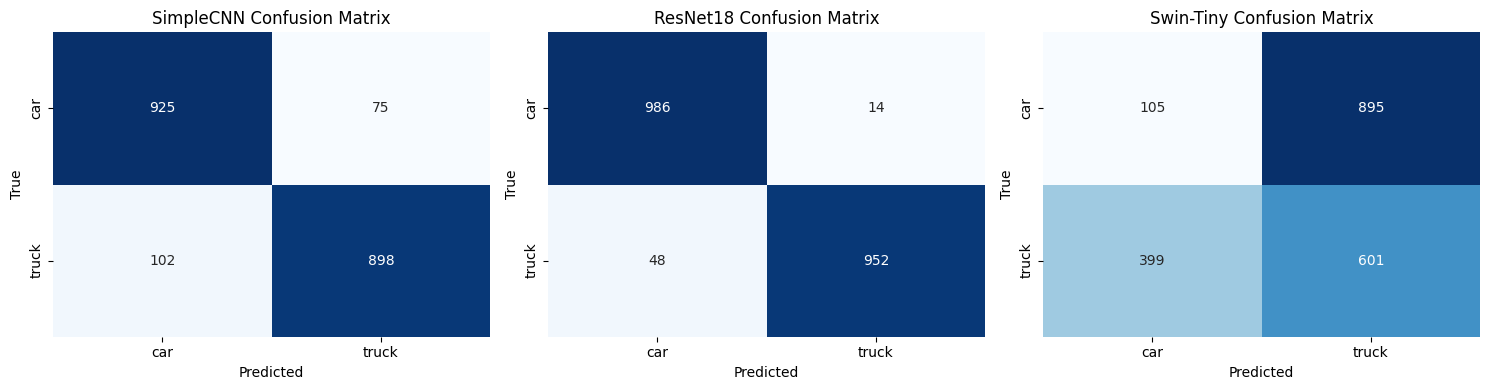

Eval device: mps
CUDA available: False


In [ ]:
models = []
if "simple_cnn" in globals():
    models.append(("SimpleCNN", simple_cnn, "cnn"))
if "resnet_model" in globals():
    models.append(("ResNet18", resnet_model, "resnet"))
if "swin_model" in globals():
    models.append(("Swin-Tiny", swin_model, "swin"))

results, cms = evaluate_models(models, test_loader, device=str(device), threshold=0.5)

display(results.round(4))
plot_confusion_matrices(cms, labels=("car", "truck"))

## 7. Experimental Results